In [1]:
from __future__ import annotations

from operator import add
from typing import TypedDict,Annotated,List,Literal

from pydantic import BaseModel,Field
from langgraph.graph import StateGraph,START,END, add_messages
from langgraph.types import Send

from pathlib import Path
import re

from prompts import ORCHESTRATOR_PROMPT,WORKER_PROMPT

from langchain_openai import ChatOpenAI
from langchain.messages import SystemMessage,HumanMessage

from dotenv import load_dotenv
load_dotenv()

d:\AI\Agentic-AI\Blog Agent\prompts.py:32: SyntaxWarning: invalid escape sequence '\['
  WORKER_PROMPT = """


True

`from __future__ import annotations` does not throw error when you instantiate a class that is not yet defined. It does not perform validations (accross type hinting) at runtime rather store them as strings and perform them later. 

Example: In the below example there are two classes referencing each other. When we are creating the class profile the User has not been created but yet used in the during the creation of profile.
```
from __future__ import annotations
class profile:
    def __init__(self,user: User):
        self.user = user
        
class User:
    def __init__(self,profile: Profile):
        self.profile = Profile
```


About the project: We will take the `state['topic']` from the user, according to which orchestrator will create a plan. This plan will contain some N numbers of tasks which will be executed by N number of worker nodes each creating a section (task) of the blog. The output of each worker is stored inside the section. These individual sections are then combined by a reducer and presented as .md file.

In [2]:
class Task(BaseModel):
    id:str
    title: str
    
    goal:str = Field(
        description="a sentence describing what the reader should be able to understand after reading this section."
        )
    
    bullets: List[str] = Field(
        min_length=3,
        max_length=6,
        description="3-6 concrete non-overlapping subpoints to cover in this section."
    )
    
    target_words:int = Field(
        ...,description="Target word count for this section (120-450)"
        )
    
    # ... means mandatory field; if not present here still same
    section_type:Literal[
        "intro","core","examples","checklist","common_mistakes","conclusion"] = Field(
        ...,description="Type of this section. Use common_mistakes exactly once in the plan."
    )


In [3]:
class Plan(BaseModel):
    blog_title: str
    tasks: List[Task]
    audience: str = Field(description="type of audience for whom this blog is for.")
    tone:str = Field(description=" Tone of writing (eg. detailed, practical, formal, crisp)")

In [4]:
class State(TypedDict):
    topic: str 
    plan : Plan
    sections : Annotated[List[str],add]
    final: str

`operator.add` is a reducer function that will concatenate the result(str) from each worker inside the list called sections. 

In [5]:
model = ChatOpenAI(model = "gpt-4.1-mini-2025-04-14")

In [6]:
def orchestrator(state: State) -> dict:
    plan = model.with_structured_output(Plan).invoke(
        [
            SystemMessage(content = ORCHESTRATOR_PROMPT),
            HumanMessage(content = f"topic = {state['topic']} "),
        ]
    )
    return {"plan":plan}

Now, we have tasks defined inside the our plan, we need to spawn the worker nodes which we can do using the Send function. Fanout is only a helper function to spawn worker nodes. It is not actually a node itself.

In [7]:
def fanout(state: State) -> List:
    sends = []
    for task in state['plan'].tasks:
        sends.append(Send("worker",arg= {"task":task, "plan": state['plan'], "topic":state['topic']}))
    return sends

In [8]:
def worker(payload:dict)-> dict:

    task: Task = payload['task']
    topic = payload['topic']
    plan: Plan = payload['plan']

    section_md = model.invoke(
        [
            SystemMessage(content =  WORKER_PROMPT),
            HumanMessage(
                content = (
                    f"Topic: {topic}\n\n"
                    f"Blog: {plan.blog_title}\n"
                    f"Section:{task.title}\n"
                    f"Goal: {task.goal}\n"
                    f"Type of Audience: {plan.audience}\n"
                    f"Tone of writing: {plan.tone}\n"
                    f"Target Words: {task.target_words}\n"
                    f"Bullet Points: {task.bullets}\n"
                )
            )
        ]
    ).content.strip()

    return {"sections":[section_md]}

In [9]:
def reducer(state: State) -> dict:
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()

    final_md = f"# {title}\n\n{body}\n"

    # Create safe filename, anything that is not a-z or A-Z or 0-9 and -,_ replace with _
    safe_title = re.sub(r'[^a-zA-Z0-9_-]', '_', title.lower())

    output_dir = Path("test_blogs")
    output_dir.mkdir(parents=True, exist_ok=True)

    output_path = output_dir / f"{safe_title}.md"
    output_path.write_text(final_md, encoding="utf-8")

    return {"final": final_md}

In [10]:
builder = StateGraph(State)
builder.add_node("orchestrator",action = orchestrator) # Name, fucntion or runnable this node will run
builder.add_node("worker",worker)
builder.add_node("reducer",reducer)

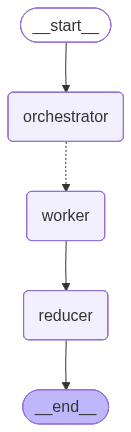

In [11]:
builder.add_edge(START,"orchestrator")
builder.add_conditional_edges("orchestrator",fanout,["worker"]) # orchestrator -> fanout -> List of worker nodes
builder.add_edge("worker","reducer")
builder.add_edge("reducer",END)

graph = builder.compile()
graph


In [12]:
response = graph.invoke({"topic":"Write a blog on Self attention"})

In [13]:
response

{'topic': 'Write a blog on Self attention',
 'plan': Plan(blog_title='Mastering Self-Attention: The Core Mechanism Powering Transformer Models', tasks=[Task(id='1', title='Introduction to Self-Attention and Its Importance', goal='Explain what self-attention is and why it is fundamental in modern NLP architectures like Transformers.', bullets=['Define self-attention at a high level and contrast it briefly with traditional attention mechanisms.', 'Illustrate the role of self-attention in modeling dependencies within a single input sequence.', 'Explain why self-attention enables parallelization and better context capture compared to RNNs and CNNs.', 'Mention key transformer models (e.g., BERT, GPT) that use self-attention as a backbone.', 'Set expectations for the technical depth and coding examples coming in the blog.'], target_words=350, section_type='intro'), Task(id='2', title='Core Concepts and Mathematical Foundations of Self-Attention', goal='Break down the mathematical formulation